<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Entrenamiento de Red Neuronal Convolucional (CNN) con datos de fríjol</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Febrero de 2026</div>

  <div style="height:0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de librerías necesarias para el entrenamiento de una Red Neuronal Convolucional (Convolutional Neural Network - CNN) con TensorFlow/Keras para la clasificación de imágenes multiespectrales de plantas de frijol.

In [7]:
# TensorFlow y Keras para construcción de redes neuronales convolucionales
import tensorflow as tf
from tensorflow.keras import layers, models

import os
from pathlib import Path
import re
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score, cohen_kappa_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Semilla para reproducibilidad
tf.keras.utils.set_random_seed(42)

# 1. Carga de Datos

Esta sección carga y prepara las imágenes multiespectrales de plantas de frijol para el entrenamiento del modelo.

## 1.1. Configuración de parámetros de carga

Se definen los hiperparámetros fundamentales para el procesamiento de imágenes:
- **Tamaño de imagen**: Redimensionamiento estándar para consistencia del modelo
- **Batch size**: Número de imágenes procesadas simultáneamente

Estrategia de partición para mejorar estabilidad del entrenamiento sin fuga hacia test:
- **Pool de entrenamiento**: unión de carpetas `train` + `val`
- **Validación interna**: partición estratificada sobre ese pool (solo para tuning/early stopping)
- **Testing final**: carpeta `test` completamente separada para evaluación final

In [8]:
# Configuración de hiperparámetros para carga de imágenes
batch_size = 32        
img_height = 180       
img_width = 180        

In [9]:

# Directorios con imágenes separadas por split
base_dir = "extracted_objects_frijol_split"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Construcción de un pool train+val para crear validación interna estratificada
pool_dirs = [train_dir, val_dir]
pool_records = []
for src_dir in pool_dirs:
    for cls_name in sorted(os.listdir(src_dir)):
        cls_path = os.path.join(src_dir, cls_name)
        if not os.path.isdir(cls_path):
            continue
        for img_path in Path(cls_path).rglob("*.png"):
            pool_records.append({
                "filepath": str(img_path),
                "class_name": cls_name,
            })

pool_df = pd.DataFrame(pool_records)
if pool_df.empty:
    raise ValueError("No se encontraron imágenes en el pool train+val.")

class_names = sorted(pool_df["class_name"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
pool_df["label"] = pool_df["class_name"].map(class_to_idx).astype(int)

# Split interno estratificado para entrenamiento/validación
train_paths, val_paths, train_labels, val_labels = train_test_split(
    pool_df["filepath"].values,
    pool_df["label"].values,
    test_size=0.20,
    random_state=42,
    stratify=pool_df["label"].values,
 )

print(f"Pool total (train+val carpetas): {len(pool_df):,} imágenes")
print(f"Train interno: {len(train_paths):,} | Val interna: {len(val_paths):,}")
print("Clases:", class_names)


Pool total (train+val carpetas): 3,230 imágenes
Train interno: 2,584 | Val interna: 646
Clases: ['T1', 'T2', 'T3', 'T4']


In [10]:
# Función de lectura y preprocesamiento
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=1)
    image = tf.image.resize(image, [img_height, img_width])
    image = tf.cast(image, tf.float32)
    return image, label

# Dataset de entrenamiento interno
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_paths), seed=123, reshuffle_each_iteration=True)
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size)

# Dataset de validación interna
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size)

# Dataset de testing final (siempre separado)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    class_names=class_names,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale',
    shuffle=False
)

Found 600 files belonging to 4 classes.


In [11]:
# Verificación de clases y distribución
print("Clases:", class_names)

def contar_por_clase(ds, class_names):
    conteo = np.zeros(len(class_names), dtype=int)
    for _, labels in ds.unbatch():
        conteo[int(labels.numpy())] += 1
    return pd.Series(conteo, index=class_names)

print("\nDistribución por clase (train interno):")
print(contar_por_clase(train_ds, class_names))

print("\nDistribución por clase (val interno):")
print(contar_por_clase(val_ds, class_names))

print("\nDistribución por clase (test):")
print(contar_por_clase(test_ds, class_names))

Clases: ['T1', 'T2', 'T3', 'T4']

Distribución por clase (train interno):
T1    648
T2    648
T3    648
T4    640
dtype: int64

Distribución por clase (val interno):
T1    162
T2    162
T3    162
T4    160
dtype: int64

Distribución por clase (test):
T1    150
T2    150
T3    150
T4    150
dtype: int64


In [12]:

# Auditoría de dominio: pool de entrenamiento (train+val) vs test
records_pool = []
for src_split in ["train", "val"]:
    split_path = Path(base_dir) / src_split
    for img_path in split_path.rglob("*.png"):
        parts = img_path.parts
        split_idx = parts.index(src_split)
        cls = parts[split_idx + 1]
        m = re.search(r"(REF__\d+_T\d+R\d+)__obj_(\d+)\.png$", img_path.name)
        if not m:
            continue
        plant_id = m.group(1)
        obj_id = int(m.group(2))
        object_id = f"{plant_id}__obj_{obj_id:03d}"
        records_pool.append({
            "group": "pool",
            "class": cls,
            "plant_id": plant_id,
            "object_id": object_id,
            "path": str(img_path),
        })

records_test = []
test_path = Path(base_dir) / "test"
for img_path in test_path.rglob("*.png"):
    parts = img_path.parts
    split_idx = parts.index("test")
    cls = parts[split_idx + 1]
    m = re.search(r"(REF__\d+_T\d+R\d+)__obj_(\d+)\.png$", img_path.name)
    if not m:
        continue
    plant_id = m.group(1)
    obj_id = int(m.group(2))
    object_id = f"{plant_id}__obj_{obj_id:03d}"
    records_test.append({
        "group": "test",
        "class": cls,
        "plant_id": plant_id,
        "object_id": object_id,
        "path": str(img_path),
    })

audit_df = pd.DataFrame(records_pool + records_test)
if audit_df.empty:
    raise ValueError("No se detectaron imágenes para auditoría.")

# 1) Coherencia etiqueta-carpeta vs token en nombre
audit_df["class_from_name"] = audit_df["plant_id"].str.extract(r"_T(\d+)")[0].astype(int).map(lambda x: f"T{x}")
mismatch = audit_df[audit_df["class"] != audit_df["class_from_name"]]
print("Mismatch carpeta vs nombre:", len(mismatch))
if len(mismatch) > 0:
    raise ValueError("Etiquetas inconsistentes entre carpeta y nombre de archivo.")

# 2) Validación anti-cruce a nivel de OBJETO (crítico: ningún object_id debe cruzar)
pool_objects = set(audit_df.loc[audit_df["group"] == "pool", "object_id"].unique())
test_objects = set(audit_df.loc[audit_df["group"] == "test", "object_id"].unique())
overlap_objects = pool_objects.intersection(test_objects)
print(f"Cruce objetos/hojas pool-test: {len(overlap_objects)}")
if overlap_objects:
    raise ValueError(f"CRUCE DETECTADO: {len(overlap_objects)} objetos aparecen en pool y test.")

# 3) Cruce a nivel de PLANTA (informativo: esperado, ya que el split es por hoja)
#    Una misma planta puede tener hojas en train y en test por diseño del dataset.
pool_plants = set(audit_df.loc[audit_df["group"] == "pool", "plant_id"].unique())
test_plants = set(audit_df.loc[audit_df["group"] == "test", "plant_id"].unique())
overlap_plants = pool_plants.intersection(test_plants)
print(f"Plantas compartidas pool-test (esperado, split por hoja): {len(overlap_plants)}")

# 4) Objetos y plantas únicas por grupo/clase
print("\nObjetos únicos por grupo y clase:")
print(audit_df.groupby(["group", "class"])["object_id"].nunique().unstack(fill_value=0).to_string())

print("\nPlantas únicas por grupo y clase:")
print(audit_df.groupby(["group", "class"])["plant_id"].nunique().unstack(fill_value=0).to_string())

print("\nVALIDACIÓN ANTI-CRUCE A NIVEL DE OBJETO: APROBADA")


Mismatch carpeta vs nombre: 0
Cruce objetos/hojas pool-test: 0
Plantas compartidas pool-test (esperado, split por hoja): 12

Objetos únicos por grupo y clase:
class  T1  T2  T3  T4
group                
pool   81  81  81  80
test   15  15  15  15

Plantas únicas por grupo y clase:
class  T1  T2  T3  T4
group                
pool    3   3   3   3
test    3   3   3   3

VALIDACIÓN ANTI-CRUCE A NIVEL DE OBJETO: APROBADA


## 1.2. Visualización exploratoria de los datos

Inspección visual de muestras del dataset para verificar la correcta carga de imágenes y la calidad de los datos.

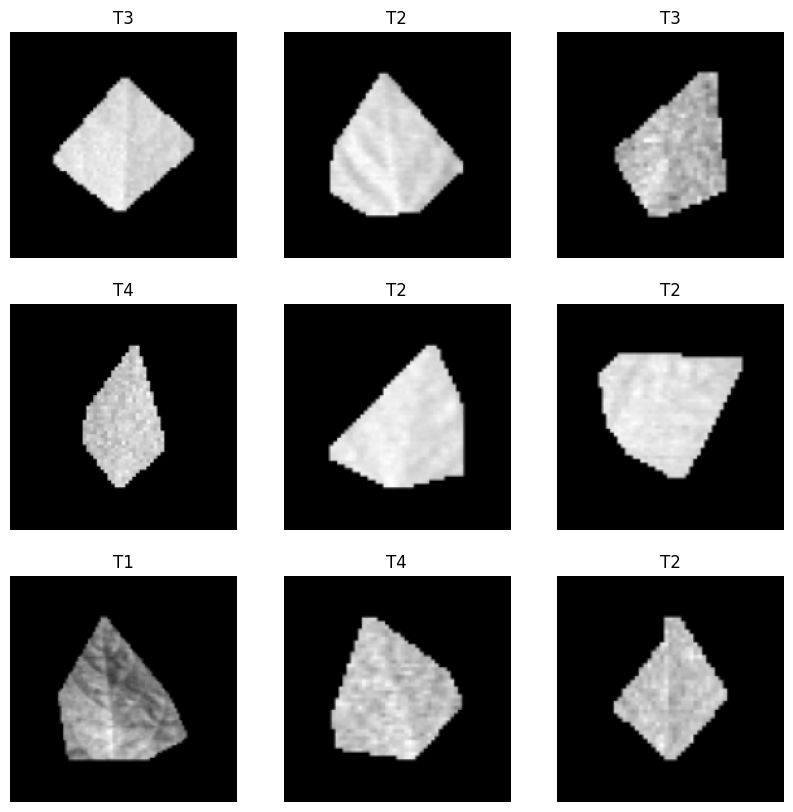

In [13]:
# Visualización de 9 imágenes de muestra del conjunto de entrenamiento
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   # Toma un batch
  for i in range(9):                      # Muestra primeras 9 imágenes
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")  # Visualización en escala de grises
    plt.title(class_names[labels[i]])     # Título con la clase correspondiente
    plt.axis("off")                       

In [14]:
# Verificación de las dimensiones de los batches
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)   # (batch_size, height, width, channels)
  print(labels_batch.shape)  # (batch_size,)
  break                      # Solo muestra el primer batch

(32, 180, 180, 1)
(32,)


# 2. Construcción del Modelo CNN

**Componentes de la CNN:**
1. **Capas Convolucionales (Conv2D)**: Aplican filtros para detectar características locales
2. **Capas de Pooling (MaxPooling2D)**: Reducen dimensionalidad preservando información relevante
3. **Capa de Aplanamiento (Flatten)**: Convierte matriz 2D en vector 1D
4. **Capas Densas (Dense)**: Clasificación final basada en características extraídas

## 2.1. Optimización del pipeline de datos

Se configuran técnicas de optimización para maximizar la eficiencia del entrenamiento:
- **Caching**: Mantiene datos en memoria después de la primera época
- **Prefetching**: Prepara el siguiente batch mientras se procesa el actual

In [15]:
# Configuración automática de buffer de prefetching
AUTOTUNE = tf.data.AUTOTUNE  # TensorFlow ajusta dinámicamente el tamaño del buffer

# Aplicación de optimizaciones a los conjuntos
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 2.2. Definición de la arquitectura CNN

Se construye una CNN secuencial con tres bloques convolucionales seguidos de capas densas para clasificación.

In [16]:
# Definición del número de clases de salida
num_classes = len(class_names)

# Data augmentation para mejorar generalización
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15),
])

# Construcción de CNN con regularización
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 1)),
    layers.Rescaling(1.0 / 255),
    data_augmentation,

    layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.20),

    layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.30),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.40),
    layers.Dense(num_classes)
])

In [17]:
# Visualización de la arquitectura del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
# Compilación del modelo con optimizador, función de pérdida y métricas
model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

# 3. Entrenamiento del modelo

In [19]:
# Cálculo de class weights para compensar desbalance en entrenamiento
y_train_labels = np.array([int(y.numpy()) for _, y in train_ds.unbatch()])
classes = np.unique(y_train_labels)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_labels)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

# Rutas de salida
best_model_path = 'models/frijol/frijol_model_cnn_v2.keras'
os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

# Callbacks anti-overfitting
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger('results/training_history_frijol_cnn_v2.csv', append=False)
]

# Entrenamiento del modelo con validación
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=80,
  class_weight=class_weight,
  callbacks=callbacks
)

Class weights: {0: 0.9969135802469136, 1: 0.9969135802469136, 2: 0.9969135802469136, 3: 1.009375}
Epoch 1/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2501 - loss: 1.4795
Epoch 1: val_loss improved from None to 1.44702, saving model to models/frijol/frijol_model_cnn_v2.keras

Epoch 1: finished saving model to models/frijol/frijol_model_cnn_v2.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.2616 - loss: 1.4366 - val_accuracy: 0.2508 - val_loss: 1.4470 - learning_rate: 0.0010
Epoch 2/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2858 - loss: 1.4096
Epoch 2: val_loss did not improve from 1.44702
81/81 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.2918 - loss: 1.4034 - val_accuracy: 0.2508 - val_loss: 1.4737 - learning_rate: 0.0010
Epoch 3/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2959 - loss: 1.4025
Epoch 3: val_loss did not improve from 1.44702
81/81 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.3003 - loss: 1.3974 - val_accuracy: 0.2508 - 

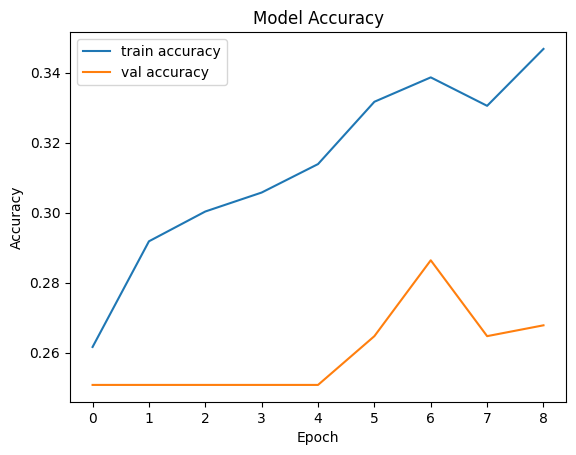

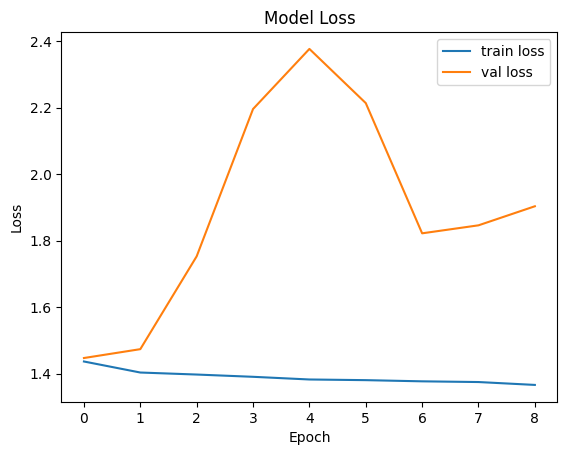

In [20]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 4. Evaluación del Modelo

Esta sección analiza el rendimiento del modelo entrenado mediante:
- **Curvas de aprendizaje**: Evolución de accuracy y loss durante el entrenamiento
- **Métricas de clasificación**: Precisión, Recall, F1-Score por clase
- **Matrices de confusión**: Visualización de aciertos y errores de clasificación

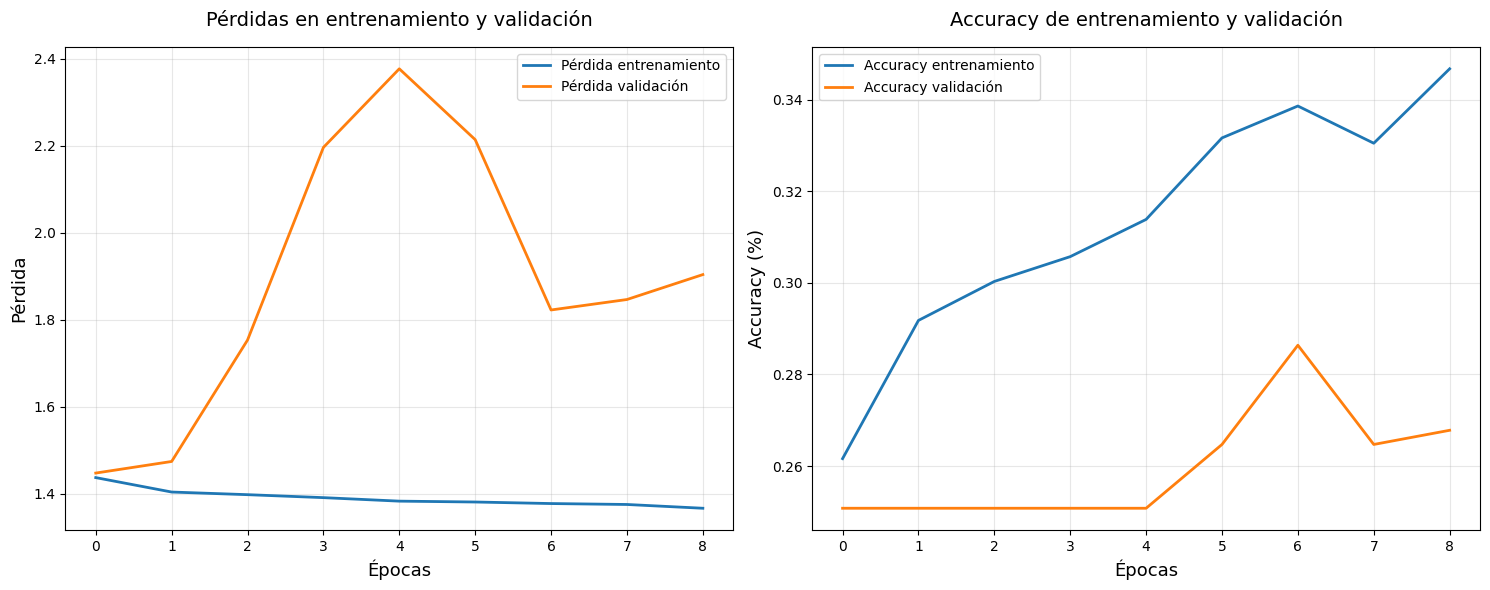

In [21]:
# Carga del historial de entrenamiento desde archivo CSV
history_data = pd.read_csv("results/training_history_frijol_cnn_v2.csv")

# Extracción de épocas para el eje X
epochs = history_data['epoch']

# Creación de visualización de métricas de entrenamiento
plt.figure(figsize=(15, 6))

# Gráfico de evolución de la pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['loss'], label='Pérdida entrenamiento', linewidth=2, color='#1f77b4')
plt.plot(epochs, history_data['val_loss'], label='Pérdida validación', linewidth=2, color='#ff7f0e')
plt.title('Pérdidas en entrenamiento y validación', fontsize=14, pad=15)
plt.xlabel('Épocas', fontsize=13)
plt.ylabel('Pérdida', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de evolución de la exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['accuracy'], label='Accuracy entrenamiento', linewidth=2, color='#1f77b4')
plt.plot(epochs, history_data['val_accuracy'], label='Accuracy validación', linewidth=2, color='#ff7f0e')
plt.title('Accuracy de entrenamiento y validación', fontsize=14, pad=15)
plt.xlabel('Épocas', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Guardar modelo

In [22]:
# Persistencia del modelo entrenado en formato Keras
model.save("models/frijol/frijol_model_cnn_v2.keras")
print("Model saved successfully as 'models/frijol/frijol_model_cnn_v2.keras'")

Model saved successfully as 'models/frijol/frijol_model_cnn_v2.keras'


## 5. Análisis Detallado de Resultados

Se carga el modelo entrenado y se generan métricas exhaustivas de rendimiento para evaluar su capacidad de generalización.

In [23]:
# Carga del modelo CNN entrenado desde archivo
trained_model = tf.keras.models.load_model('models/frijol/frijol_model_cnn_v2.keras')

In [24]:
trained_model = model

In [25]:
# Obtener etiquetas reales y predicciones del conjunto de testing final
y_test_true = []
y_test_pred = []

print("Realizando predicciones sobre el conjunto de testing...")
for images, labels in test_ds:
    preds = trained_model.predict(images, verbose=0)
    y_test_true.extend(labels.numpy())
    y_test_pred.extend(np.argmax(preds, axis=1))

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)

# Generación de predicciones para el conjunto de entrenamiento
y_train_true = []
y_train_pred = []

print("Realizando predicciones sobre el conjunto de entrenamiento...")
for images, labels in train_ds:
    preds = trained_model.predict(images, verbose=0)
    y_train_true.extend(labels.numpy())
    y_train_pred.extend(np.argmax(preds, axis=1))

y_train_true = np.array(y_train_true)
y_train_pred = np.array(y_train_pred)

Realizando predicciones sobre el conjunto de testing...
Realizando predicciones sobre el conjunto de entrenamiento...


In [26]:
# Métricas del conjunto de Test
accuracy = accuracy_score(y_test_true, y_test_pred)
precision = precision_score(y_test_true, y_test_pred, average='weighted')
f1 = f1_score(y_test_true, y_test_pred, average='weighted')
kappa = cohen_kappa_score(y_test_true, y_test_pred)

# Métricas del conjunto de Train
train_accuracy = accuracy_score(y_train_true, y_train_pred)
train_precision = precision_score(y_train_true, y_train_pred, average='weighted')
train_f1 = f1_score(y_train_true, y_train_pred, average='weighted')
train_kappa = cohen_kappa_score(y_train_true, y_train_pred)

# Presentación comparativa de resultados
print("-" * 65)
print(f"{'Métrica':<20} | {'Train':<20} | {'Test':<20}")
print("-" * 65)
print(f"{'Accuracy':<20} | {train_accuracy:<20.4f} | {accuracy:<20.4f}")
print(f"{'Precision':<20} | {train_precision:<20.4f} | {precision:<20.4f}")
print(f"{'F1-Score':<20} | {train_f1:<20.4f} | {f1:<20.4f}")
print(f"{'Kappa Score':<20} | {train_kappa:<20.4f} | {kappa:<20.4f}")
print("-" * 65)

-----------------------------------------------------------------
Métrica              | Train                | Test                
-----------------------------------------------------------------
Accuracy             | 0.2508               | 0.2500              
Precision            | 0.0629               | 0.0625              
F1-Score             | 0.1006               | 0.1000              
Kappa Score          | 0.0000               | 0.0000              
-----------------------------------------------------------------


d:\1. Biblioteca Usuario\Documents\UNAL\MAESTRÍA\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\1. Biblioteca Usuario\Documents\UNAL\MAESTRÍA\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
# Reporte de Clasificación
print("\nReporte de Clasificación (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

print("\nReporte de Clasificación (Train):")
print(classification_report(y_train_true, y_train_pred, target_names=class_names))


Reporte de Clasificación (Test):
              precision    recall  f1-score   support

          T1       0.25      1.00      0.40       150
          T2       0.00      0.00      0.00       150
          T3       0.00      0.00      0.00       150
          T4       0.00      0.00      0.00       150

    accuracy                           0.25       600
   macro avg       0.06      0.25      0.10       600
weighted avg       0.06      0.25      0.10       600


Reporte de Clasificación (Train):
              precision    recall  f1-score   support

          T1       0.25      1.00      0.40       648
          T2       0.00      0.00      0.00       648
          T3       0.00      0.00      0.00       648
          T4       0.00      0.00      0.00       640

    accuracy                           0.25      2584
   macro avg       0.06      0.25      0.10      2584
weighted avg       0.06      0.25      0.10      2584



d:\1. Biblioteca Usuario\Documents\UNAL\MAESTRÍA\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\1. Biblioteca Usuario\Documents\UNAL\MAESTRÍA\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\1. Biblioteca Usuario\Documents\UNAL\MAESTRÍA\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-de

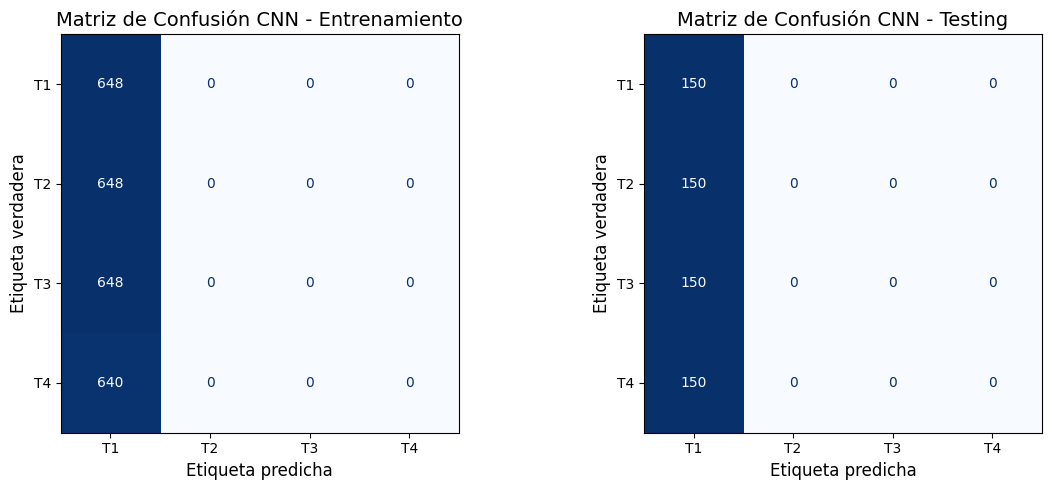

In [28]:
# Visualización comparativa de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de confusión para conjunto de entrenamiento
cm_train = confusion_matrix(y_train_true, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión CNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de confusión para conjunto de prueba
cm_test = confusion_matrix(y_test_true, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión CNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()